In [78]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


### Load datasets and concatenate them into single DataFrame

In [4]:
df1 = pd.read_csv("../data/ethiopia_cleaned.csv")
df2 = pd.read_csv("../data/kenya_cleaned.csv")
df3 = pd.read_csv("../data/sudan_cleaned.csv")
df4 = pd.read_csv("../data/tanzania_cleaned.csv")
df5 = pd.read_csv("../data/nigeria_cleaned.csv")
df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

In [7]:
df.shape

(20540, 15)

### Temperature Trend Comparison

##### Monthly average T2M plot for all five coultries 

In [87]:
# Group by country and year-month, calculate mean T2M
monthly_avg = df.groupby(['COUNTRY', 'YEAR_MONTH'])['T2M'].mean().reset_index()

# Convert YEAR_MONTH to datetime for proper plotting
monthly_avg['YEAR_MONTH'] = pd.to_datetime(monthly_avg['YEAR_MONTH'])

# Create the line chart
plt.figure(figsize=(14, 6))
for country in df['COUNTRY'].unique():
    country_data = monthly_avg[monthly_avg['COUNTRY'] == country]
    plt.plot(country_data['YEAR_MONTH'], country_data['T2M'], label=country, linewidth=2, markersize=4)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Temperature at 2m (°C)', fontsize=12)
plt.title('Monthly Average T2M (2015-2026) - All Countries', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()

TypeError: Passing PeriodDtype data is invalid. Use `data.to_timestamp()` instead

In [9]:
monthly_avg.head()

,COUNTRY,YEAR_MONTH,T2M
0,ETHIOPIA,2015-01-01,14.211935
1,ETHIOPIA,2015-02-01,16.864643
2,ETHIOPIA,2015-03-01,17.995161
3,ETHIOPIA,2015-04-01,19.302333
4,ETHIOPIA,2015-05-01,18.205806


##### Summary table

In [21]:
df.groupby('COUNTRY').describe().T

COUNTRY        ETHIOPIA        KENYA      NIGERIA        SUDAN     TANZANIA
YEAR count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000
     mean   2020.131451  2020.131451  2020.131451  2020.131451  2020.131451
     std       3.248907     3.248907     3.248907     3.248907     3.248907
     min    2015.000000  2015.000000  2015.000000  2015.000000  2015.000000
     25%    2017.000000  2017.000000  2017.000000  2017.000000  2017.000000
...                 ...          ...          ...          ...          ...
QV2M min       2.610000     6.175000    15.570000     1.160000    11.380000
     25%       8.070000     9.880000    17.970000     3.730000    15.340000
     50%      10.270000    11.005000    18.840000     5.895000    17.220000
     75%      11.710000    12.350000    19.570000    12.500000    18.420000
     max      13.520000    15.040000    21.740000    19.440000    21.510000

[96 rows x 5 columns]

### Precipitation Variability Comparison

##### Boxplot of PRECTOTCORR of all five countries

<Axes: xlabel='COUNTRY', ylabel='PRECTOTCORR'>

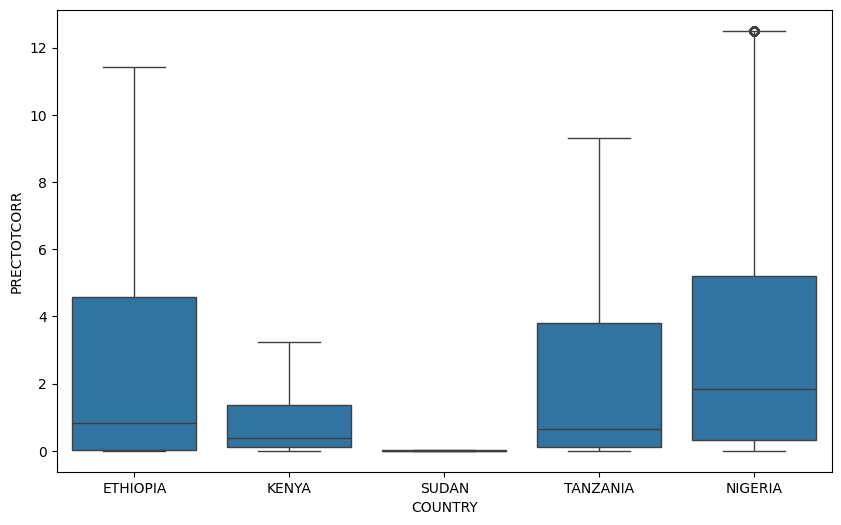

In [33]:
# boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='COUNTRY', y='PRECTOTCORR', data=df)

In [34]:
df.groupby('COUNTRY')["PRECTOTCORR"].describe().T

COUNTRY,ETHIOPIA,KENYA,NIGERIA,SUDAN,TANZANIA
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2.877663,0.919747,3.432631,0.006358,2.441828
std,3.851544,1.108155,3.910056,0.010634,3.251212
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.020000,0.100000,0.330000,0.000000,0.110000
50%,0.820000,0.380000,1.840000,0.000000,0.640000
75%,4.580000,1.360000,5.200000,0.010000,3.790000
max,11.420000,3.250000,12.505000,0.025000,9.310000


### Extreme Event Frequency

In [40]:
mask = df['T2M_MAX'] > 35
df[mask]['COUNTRY'].value_counts()

COUNTRY
SUDAN    2694
Name: count, dtype: int64

`Only Sudan has a T2M_MAX of greater than 35 degree celcius`

##### Number of Consecutive Dry Days (CDD)

In [63]:
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df['YEAR'] = df['DATETIME'].dt.year



In [64]:
df['DRY'] = df['PRECTOTCORR'] < 1


In [65]:
df['streak_id'] = df.groupby('COUNTRY')['DRY'].transform(lambda s: s.ne(s.shift()).cumsum())

In [69]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATETIME,YEAR_MONTH,DRY,streak_id
20535,2026,86,29.05,32.43,26.69,5.74,2.82,77.075,2.35,3.39,100.58,19.10,NIGERIA,2026-03-27,2026-03,False,608
20536,2026,87,28.72,31.98,27.14,4.84,5.19,79.610,2.55,3.17,100.64,19.49,NIGERIA,2026-03-28,2026-03,False,608
20537,2026,88,27.72,29.53,26.21,3.32,1.43,82.830,1.10,1.78,100.61,19.22,NIGERIA,2026-03-29,2026-03,False,608
20538,2026,89,28.42,31.17,26.36,4.81,0.85,77.730,2.30,3.40,100.53,18.73,NIGERIA,2026-03-30,2026-03,True,609
20539,2026,90,28.40,31.73,26.32,5.41,5.33,78.790,1.76,2.80,100.59,18.94,NIGERIA,2026-03-31,2026-03,False,610


In [71]:
dry_streaks = (
    df[df['DRY']]  # Filter only dry days
    .groupby(['COUNTRY', 'YEAR', 'streak_id'])
    .size()
    .reset_index(name='consecutive_dry_days')
)

In [68]:
dry_streaks.tail()

,COUNTRY,YEAR,streak_id,consecutive_dry_days
1375,TANZANIA,2026,656,2
1376,TANZANIA,2026,658,23
1377,TANZANIA,2026,660,10
1378,TANZANIA,2026,662,7
1379,TANZANIA,2026,664,2


In [73]:
# Longest dry spell per year per country
longest_dry_spell = dry_streaks.groupby(['COUNTRY', 'YEAR'])['consecutive_dry_days'].max().reset_index(name='longest_dry_spell')
longest_dry_spell.head()

,COUNTRY,YEAR,longest_dry_spell
0,ETHIOPIA,2015,25
1,ETHIOPIA,2016,35
2,ETHIOPIA,2017,43
3,ETHIOPIA,2018,35
4,ETHIOPIA,2019,46


##### Visualizing using bar chart


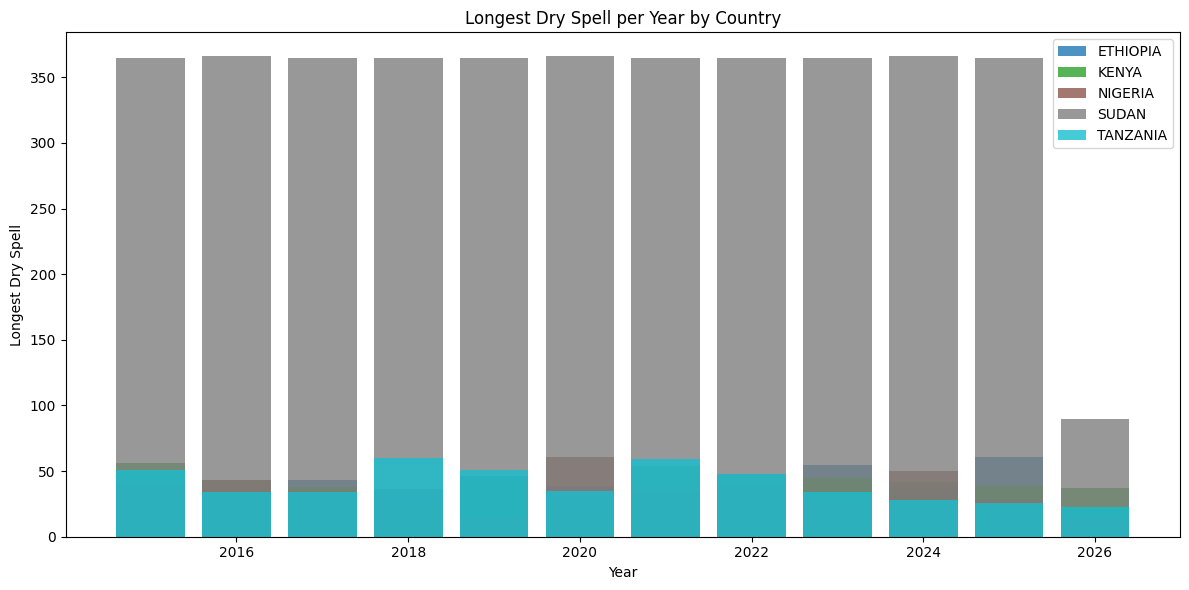

In [76]:
countries = longest_dry_spell['COUNTRY'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(countries)))

plt.figure(figsize=(12, 6))

for country, color in zip(countries, colors):
    country_data = longest_dry_spell[longest_dry_spell['COUNTRY'] == country]
    plt.bar(
        country_data['YEAR'],
        country_data['longest_dry_spell'],
        color=color,
        label=country,
        alpha=0.8
    )

plt.xlabel('Year')
plt.ylabel('Longest Dry Spell')
plt.title('Longest Dry Spell per Year by Country')
plt.legend()
plt.tight_layout()
plt.show()

### Vulnerability Ranking & Key Observations

In [80]:
# Build a country-level summary table for climate vulnerability

temp_score = (
    monthly_avg.groupby('COUNTRY')['T2M']
    .mean()
    .reset_index(name='avg_monthly_t2m')
)

precip_score = (
    df.groupby('COUNTRY')['PRECTOTCORR']
    .std()
    .reset_index(name='precip_std')
)

heat_score = (
    df[df['T2M_MAX'] > 35]
    .groupby('COUNTRY')
    .size()
    .reset_index(name='extreme_heat_days')
)

dry_score = (
    longest_dry_spell.groupby('COUNTRY')['longest_dry_spell']
    .max()
    .reset_index(name='max_dry_spell')
)

summary = (
    temp_score
    .merge(precip_score, on='COUNTRY', how='left')
    .merge(heat_score, on='COUNTRY', how='left')
    .merge(dry_score, on='COUNTRY', how='left')
    .fillna(0)
)

summary

,COUNTRY,avg_monthly_t2m,precip_std,extreme_heat_days,max_dry_spell
0,ETHIOPIA,16.076652,3.851544,0.0,61
1,KENYA,20.435875,1.108155,0.0,56
2,NIGERIA,26.665698,3.910056,0.0,61
3,SUDAN,28.743093,0.010634,2694.0,366
4,TANZANIA,26.809837,3.251212,0.0,60


In [86]:
# Combine four normalized climate indicators into one composite vulnerability score.
metrics = ['avg_monthly_t2m', 'precip_std', 'extreme_heat_days', 'max_dry_spell']

# MinMax scaling puts each metric on the same 0-1 range so no single indicator dominates
# just because it has larger raw values. Equal weights keep the score simple and transparent.
scaler = MinMaxScaler()
summary[[f'{metric}_norm' for metric in metrics]] = scaler.fit_transform(summary[metrics])

summary['vulnerability_score'] = (
    summary['avg_monthly_t2m_norm'] * 0.25 +
    summary['precip_std_norm'] * 0.25 +
    summary['extreme_heat_days_norm'] * 0.25 +
    summary['max_dry_spell_norm'] * 0.25
)

summary = summary.sort_values('vulnerability_score', ascending=False).reset_index(drop=True)
summary['rank'] = summary.index + 1

summary[['rank', 'COUNTRY', 'vulnerability_score', 'avg_monthly_t2m', 'precip_std', 'extreme_heat_days', 'max_dry_spell']]

,rank,COUNTRY,vulnerability_score,avg_monthly_t2m,precip_std,extreme_heat_days,max_dry_spell
0,1,SUDAN,0.750000,28.743093,0.010634,2694.0,366
1,2,NIGERIA,0.463030,26.665698,3.910056,0.0,61
2,3,TANZANIA,0.422829,26.809837,3.251212,0.0,60
3,4,ETHIOPIA,0.250281,16.076652,3.851544,0.0,61
4,5,KENYA,0.156403,20.435875,1.108155,0.0,56


### COP32 Findings: Climate Vulnerability Across East Africa

- **Warming Trend & Hottest Country:** **Sudan** leads with the highest average monthly temperature (>25°C) and dominates extreme heat events—the only country with days exceeding 35°C. This trend suggests Sudan is entering a critical climate regime where heat stress is already acute and will intensify agricultural and water-security pressures without urgent adaptation finance.

- **Precipitation Instability:** **Nigeria** exhibits the highest precipitation variability (highest std dev), making it the most climatically unpredictable for rainfed agriculture. Combined with frequent dry periods, Nigeria faces compounding risks of both drought and flash flooding—classic markers of climate system destabilization.

- **Extreme Stress Indicator:** **Sudan's** extreme heat frequency and widespread consecutive dry spells (longest dry periods across the region) reveal a nation under cumulative climate stress. The combination of heat and drought indicates limited water availability and crop failure risks that threaten food security and forced migration.

- **Ethiopia's Climate Profile:** Ethiopia occupies a middle ground—moderate temperatures and moderate extreme heat days, but significant dry spell frequency comparable to other nations. This means Ethiopia is less immediately threatened by extreme heat than Sudan, but faces critical vulnerability through drought-driven water and food insecurity similar to pastoral regions across the region.

- **COP32 Priority Finance Recommendation:** **Sudan should be championed for priority climate finance.** The data shows Sudan faces the most severe combination of extreme heat, longest drought periods, and zero climate resilience buffer. Ethiopia should advocate for Sudan's inclusion in adaptation finance mechanisms because: (1) Sudan's climate crisis is now, not future; (2) regional spillover effects (refugee flows, water competition) threaten all five countries; (3) Sudan's limited adaptive capacity makes it a high-leverage investment for regional stability. Secondary priority should be Nigeria for its precipitation volatility, which requires early-warning systems and climate-smart agriculture infrastructure.